In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.model_selection import train_test_split
import pandas as pd
from nltk import word_tokenize 

In [2]:
# 1. load the data
train = pd.read_csv("../../data/lang_train.csv")
test = pd.read_csv("../../data/lang_test.csv")

train = train[train["labels"].isin(["de", "es", "en"])]
test = test[test["labels"].isin(["de", "es", "en"])]

texts_train = list(train["text"].values)
texts_test = list(test["text"].values)
labels_train = list(train["labels"].values)
labels_test = list(test["labels"].values)

# Global Label Mapping
unique_labels = sorted(list(set(labels_train+labels_test)))
label_to_idx = {label: i for i, label in enumerate(unique_labels)}
NUM_CLASSES = len(unique_labels)
label_to_idx

{'de': 0, 'en': 1, 'es': 2}

### Question: 
- Take a quick look at the dataset. Is this a one-to-many, many-to-one or many-to-many problem?

In [3]:
# 2. define the vocab (doing both, char and word vocabs here)
word_corpus = []
for text in texts_train:
    word_corpus.extend([w for w in word_tokenize(text.lower()) if w.isalpha()])
    
word_vocab = sorted(list(set(word_corpus)))
word_to_id = {gram: i+1 for i, gram in enumerate(word_vocab)}

char_vocab = sorted(list(set(" ".join(texts_train).lower())))
char_to_id = {char: i+1 for i, char in enumerate(char_vocab)}

In [4]:
# 3. Encoder functions
def word_encoder(text, max_seq_len=15):
    id_seq = [0] * max_seq_len
    for i, word in enumerate(word_tokenize(text)):
        if i >= max_seq_len:
            break
        if word.isalpha(): 
            id_seq[i] = word_to_id[word.lower()]
    return id_seq

def char_encoder(text, max_seq_len=25):
    id_seq = [0] * max_seq_len
    for i, char in enumerate(list(text.lower())):
        if i >= max_seq_len:
            break
        # lookup safety using .get() to avoid KeyError for unknown characters
        id_seq[i] = char_to_id.get(char, 0)
    return id_seq

In [5]:
# 4. parameter settings
LEVEL = "char"

if LEVEL == "word":
    vocab = word_vocab
    encode = word_encoder
    MAX_SEQ_LEN = 5
else:
    vocab = char_vocab
    encode = char_encoder
    MAX_SEQ_LEN = 15

VOCAB_SIZE  = len(vocab) + 1
EMBED_DIM   = 32
HIDDEN_DIM  = 32

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset and Dataloader

PyTorch uses a ```Dataset``` to structure how data samples are fetched. In each iteration of the PyTorch training loop, a small subset of the dataset (so called ```mini-batch```) is sampled from the Dataset and used for training the neural network. The task of (randomly) sampling examples from the Dataset and bundling them together into mini-batches is handled by the ```DataLoader```.

The advantages of mini-batch training are:

- Mini-batches balance speed and stability. Full-batch training is slow and expensive, while single-sample updates are noisy. Mini-batches provide stable enough gradients with fast computation.
- They improve learning dynamics. The moderate gradient noise helps optimization converge efficiently and often improves generalization.
- They use hardware efficiently. Processing multiple samples together enables efficient GPU/TPU parallelization without the memory cost of full-batch training.

In [6]:
# Dataloader definition: In pytorch we write our own training loop, during which we iterate over
# a Pytorch-specific dataloader.
class SentenceDataset(Dataset):
    def __init__(self, texts, labels, label_mapping, max_seq_len=MAX_SEQ_LEN):
        self.texts = texts
        self.labels = labels
        self.max_seq_len = max_seq_len
        self.label_to_idx = label_mapping
        
    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # this function determines what happens when you call ```dataset[i]```
        text = self.texts[idx]
        label = self.labels[idx]
        label_id = self.label_to_idx[label]
        token_ids = torch.tensor(encode(text, self.max_seq_len)).long()
        return text, token_ids, label_id

train_dataset = SentenceDataset(texts_train, labels_train, label_to_idx)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

### Question

Fetch the third element from the training dataset. What is the respective text? What are the other return objects?

-----

### Recurrent Neural Networks

Recurrent neural networks (RNNs) extend feedforward architectures to handle sequential data by maintaining an internal state that persists across input elements. For each element $i=1,\ldots,n$ in a sequence, an RNN receives an input $x_t$ and updates its hidden state $h_t$ based on both the input and the previous hidden state $h_{t-1}$. This recurrent connection enables the network to maintain information about past inputs, making RNNs suitable for processing sequences of arbitrary length.
In its most fundamental form, the transition is defined as $h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b)$, where $W_{h}$ and $W_{x}$ are learnable weight matrices


<div>
<img src="simple_rnn.png" width="500"/>
</div>

In [7]:
# 6. Model Definitions
class RNNEncoder(nn.Module):
    """This is a Pytorch implementation of a vanilla RNN"""
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout=0.1):
        super(RNNEncoder, self).__init__()
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # maps input embedding to latent space
        self.i2h = nn.Linear(embed_dim, hidden_dim, bias=True)
        # maps current hidden state to latent space
        self.h2h = nn.Linear(hidden_dim, hidden_dim, bias=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        batch_size, seq_len = x.shape
        embedded = self.dropout(self.embedding(x)) 
        h_t = torch.zeros(batch_size, self.hidden_dim, device=x.device)
        
        # List to accumulate the hidden state at every single timestep t
        all_hidden_states = []
        
        for t in range(seq_len):
            x_t = embedded[:, t, :]
            
            # 1. Create a mask: 1.0 for real tokens, 0.0 for padding (0)
            mask = (x[:, t] != 0).float().unsqueeze(1)
            
            # 2. Compute the proposed next hidden state
            h_t_next = torch.tanh(self.i2h(x_t) + self.h2h(h_t))
            
            # 3. Conditionally update: if mask is 0, retain old h_t
            h_t = mask * h_t_next + (1.0 - mask) * h_t
            
            # Save the current state (add a temporary sequence dimension for stacking)
            all_hidden_states.append(h_t.unsqueeze(1))
        
        # Concatenate along the sequence dimension (dim=1)
        # Resulting shape: (batch_size, seq_len, hidden_dim)
        output = torch.cat(all_hidden_states, dim=1)

        return output, h_t


### Tasks and Questions:

- What is the initial hidden state $h_0$ in this RNN implementation?
- Create an instance of the RNN encoder. What is the total number of parameters (weights) of the model. How does it change when you switch from character-level tokenizer to word-level tokenizer? Why?
   - **Hint**: Neural networks are composed of several processing layers. You can use ```rnn.parameters()``` to get a generator over these layers, yielding the parameter-tensors for each of them. You can use the ```.numel()``` method to get the number of elements in a tensor.
- Fetch an element from the training dataset and feed it through the RNN. What is the output? What does each output element represent?
   - **Hint**: You can either use the ```.forward()``` method or call your RNN instance directly (i.e. ```rnn(input)```)
- Why do we implement the mask step inside the RNN loop? What error or bias would occur if we processed padded tokens ($0$) through the linear layers without masking them out?
   -  **Hint**: Check what the embedding table does if it encounters a padded token. What happens in the RNN update function if we encounter many of these?
   -  **Hint 2**: Use this to get the embeddings of some text ```rnn.embedding(torch.tensor(encode(text), dtype=torch.long).unsqueeze(0))```

-----

### Text Classifier

The RNN "only" gives us a representation of the text. In order to make a prediction, we need an additional prediction ```Layer```. 

In [8]:
class TextClassifier(nn.Module):
    """This is a Pytorch module which classifies text. It uses an RNN to encode an input
    text sequence and uses the last hidden state of the RNN to make a prediction"""
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super(TextClassifier, self).__init__()
        self.rnn = RNNEncoder(vocab_size, embed_dim, hidden_dim)
        self.lin = nn.Linear(hidden_dim, num_classes) 

    def forward(self, token_ids):
        _, text_emb = self.rnn(token_ids)
        return self.lin(text_emb)

# Initialization
model = TextClassifier(vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM, num_classes=NUM_CLASSES)
# send model to designated device
model = model.to(DEVICE)

### Questions:
- What is the output dimension of ```model```? What does each dimension tell us?
  - **Hint:** also check the ```label_to_idx``` dictionary

-----

### Trainin Loop

In contrast to sklearn where we simply call a ```.fit()``` method we have to write our own training loop in PyTorch. The training process is composed of an outer loop, which repeats the actualy training process for some number ```epoch```. The inner loop iterates over the training dataset, evaluates the loss of the current model, and updates its parameters (weights) according to this loss.
```
initialize model, optimizer, loss_fn

for epoch:
    for x, y in train_data:
        y_hat = model(x)
        loss = loss_fn(y_hat, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    optionally evaluate on validation data
```

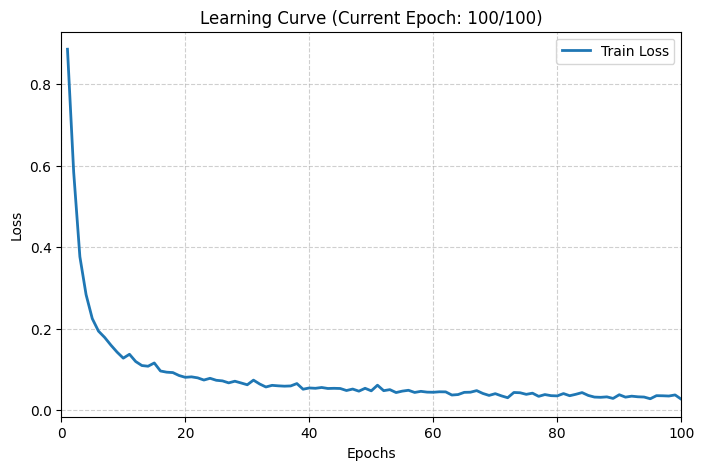

Epoch 100/100  |  Loss: 0.0266

Training complete!


In [10]:
import matplotlib.pyplot as plt
from IPython import display

# Initialization
model = TextClassifier(vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM, num_classes=NUM_CLASSES)
# send model to designated device
model = model.to(DEVICE)

# 7. Training Loop
optimiser = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

EPOCHS = 100
train_losses = []

# --- 1. Set up the figure before the loop starts ---
fig, ax = plt.subplots(figsize=(8, 5))

model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0.0
    for text, token_ids, label in train_dataloader:
        token_ids = token_ids.to(DEVICE)
        label = label.to(DEVICE)
        
        logits = model(token_ids)
        loss = loss_fn(logits, label)
        
        optimiser.zero_grad()
        loss.backward()
        optimiser.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_dataloader)
    train_losses.append(avg_loss)

    # --- 2. Live plotting logic ---
    if (epoch + 1) % 5 == 0 or epoch == 0:
        ax.cla()  # Clear the axes to repaint the line smoothly
        
        # Plot the current history
        ax.plot(range(1, len(train_losses) + 1), train_losses, color='#1f77b4', linewidth=2, label='Train Loss')
        
        # Fix the X-axis bounds as requested
        ax.set_xlim(0, EPOCHS)
        
        # Labels and styling
        ax.set_xlabel('Epochs')
        ax.set_ylabel('Loss')
        ax.set_title(f'Learning Curve (Current Epoch: {epoch+1}/{EPOCHS})')
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend()
        
        # The Jupyter magic: clear previous plot and display the updated one
        display.clear_output(wait=True)
        display.display(plt.gcf())
        
        # Print the text status right below the live plot
        print(f"Epoch {epoch+1:>3}/{EPOCHS}  |  Loss: {avg_loss:.4f}")

# Close the plot object at the end so it doesn't duplicate in the final cell output
plt.close()
print("\nTraining complete!")

In [ ]:
# 8. Evaluation Loop
test_dataset = SentenceDataset(texts_test, labels_test, label_to_idx)
test_dataloader = DataLoader(test_dataset, batch_size=4, shuffle=False)

correct = 0
incorrect = 0

model.eval()
with torch.no_grad():
    for text, token, label in test_dataloader:
        token = token.to(DEVICE)
        label = label.to(DEVICE)
        
        logits = model(token) 
        pred = torch.argmax(logits, dim=-1)
        
        correct += int((label == pred).sum())
        incorrect += int((label != pred).sum())

print(f"Accuracy: {correct / (correct + incorrect):.4f}")

### Tasks and Questions:

- Switch from a character-level tokenizer to a word-level tokenizer. Where does the code break and how can this be fixed? What problem does this fix introduce?
- Upload the notebook and the data to Google Colab (note that you might have to adjust the relative paths). Try to get an instance with a GPU and run the script again. What do you notice?